In [1]:
!pip install torch transformers scikit-learn pandas numpy matplotlib plotly spacy
!python -m spacy download nl_core_news_sm
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade "transformers[torch]"
!pip install tqdm
!pip install Datasets
!pip install seaborn

  Using cached numpy-2.3.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 5.2 MB/s eta 0:00:03
     -------- ------------------------------- 2.9/12.8 MB 6.2 MB/s eta 0:00:02
     -------------- ------------------------- 4.7/12.8 MB 6.8 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 7.3 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 7.6 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 7.5 MB/s eta 0:00:01
     ----------------------------------- ---- 11.5/12.8 MB 7.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
Looking in indexes: https://download.pytorch.org

##Run LDAprecoding_script

In [29]:
#Run LDAprecoding_script

import json

config = {
    "USE_FOLDER": True,
    "SOURCE_FOLDER_PATH": "Policyarchive_text",
    "OUTPUT_FOLDER": "Corex_topicdata_slavery_policyv1",
    "MODEL_FOLDER": "Corex_topicdata_slavery_policyv1",
    "FOLDER_MODE": False, # Set to True if you want to use simple mode
    "YEAR_FILTER": [2015,2015],
    "DOC_TYPES": ["beleidsnotas","convenanten","kamerstukken","brieven","besluiten","jaarverslagen","jaarplannen",],
    "SENTS_PER_CHUNK": 300,
    "CONFIDENCE_THRESHOLD": 0.0,
    "MIN_COSINE": 0.05,
}

with open("corex_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)




In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import os
from pathlib import Path

# ---- Set your folders here ----
OUTPUT_FOLDER = "Corex_topicdata_slavery_policyv1"
MODEL_FOLDER = "Corex_topicdata_slavery_policyv1"

RESULTS_CSV = os.path.join(OUTPUT_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(MODEL_FOLDER, "lda_topicdata.json")

# --- Load results ---
# Define the correct column order you want
correct_columns = [
    'filename', 'filepath', 'document_type', 'year', 'chunk_num',
    'chunk_text', 'topic', 'cosine', 'cosine_weighted', 'topic_probs', 'topic_assigned'
]

df = pd.read_csv(RESULTS_CSV)

# Extract correct document_type and year from filepath
def extract_from_path(filepath):
    parts = Path(str(filepath)).parts
    # Adjust indices if your folder structure differs
    document_type = parts[-3] if len(parts) >= 3 else None
    year = parts[-2] if len(parts) >= 2 else None
    return pd.Series({'document_type': document_type, 'year': year})

df[['document_type', 'year']] = df['filepath'].apply(extract_from_path)


# Reorder columns as desired (will ignore missing columns if typo)
train_source = df[[col for col in correct_columns if col in df.columns]]


# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]

In [49]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import os
from pathlib import Path

# ---- Set your folders here ----
OUTPUT_FOLDER = "Corex_topicdata_slavery_policyv1"
MODEL_FOLDER = "Corex_topicdata_slavery_policyv1"

RESULTS_CSV = os.path.join(OUTPUT_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(MODEL_FOLDER, "lda_topicdata.json")

# --- Load results ---
# Define the correct column order you want
correct_columns = [
    'filename', 'filepath', 'document_type', 'year', 'chunk_num',
    'chunk_text', 'topic', 'cosine', 'cosine_weighted', 'topic_probs', 'topic_assigned'
]

df = pd.read_csv(RESULTS_CSV)

# Extract correct document_type and year from filepath
def extract_from_path(filepath):
    parts = Path(str(filepath)).parts
    # Adjust indices if your folder structure differs
    document_type = parts[-3] if len(parts) >= 3 else None
    year = parts[-2] if len(parts) >= 2 else None
    return pd.Series({'document_type': document_type, 'year': year})

df[['document_type', 'year']] = df['filepath'].apply(extract_from_path)

# Reorder columns as desired (will ignore missing columns if typo)
train_source = df[[col for col in correct_columns if col in df.columns]]

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]

# Now `train_source` is your cleaned, standardized dataframe ready for analysis!
# Example: Save to CSV (optional)
# train_source.to_csv(os.path.join(OUTPUT_FOLDER, "chunk_topics_corex_assignments_cleaned.csv"), index=False)


In [45]:
print(train_source.chunk_text.head(3))


0                                           vindplaats
1                            nota aanleid omgevingswet
2    hierin voorzien parlementair betrok opstell am...
Name: chunk_text, dtype: object


In [50]:
print(train_source)
import ast

def all_false_from_str(val):
    # Convert string to list
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except Exception:
            return False
    # Check if list and all values are False
    return isinstance(val, list) and all(v is False for v in val)

no_topic_df = train_source[train_source['topic_assigned'].apply(all_false_from_str)]

print(f"Chunks with NO topic assigned: {len(no_topic_df)}")



                                               filename  \
0     bijlage-1-nota-naar-aanleiding-van-het-verslag...   
1     bijlage-1-nota-naar-aanleiding-van-het-verslag...   
2     bijlage-1-nota-naar-aanleiding-van-het-verslag...   
3     bijlage-1-nota-naar-aanleiding-van-het-verslag...   
4     bijlage-1-nota-naar-aanleiding-van-het-verslag...   
...                                                 ...   
6979  wetsvoorstel-wijziging-wet-educatie-en-beroeps...   
6980  wetsvoorstel-wijziging-wet-educatie-en-beroeps...   
6981  wetsvoorstel-wijziging-wet-educatie-en-beroeps...   
6982  wetsvoorstel-wijziging-wet-educatie-en-beroeps...   
6983  wetsvoorstel-wijziging-wet-educatie-en-beroeps...   

                                               filepath document_type  \
0     Policyarchive_text\beleidsnotas\2015\bijlage-1...          2015   
1     Policyarchive_text\beleidsnotas\2015\bijlage-1...          2015   
2     Policyarchive_text\beleidsnotas\2015\bijlage-1...          2015   

In [15]:
# Suppose your column is a list of cosines per topic
import numpy as np
all_cosines = np.concatenate(train_source['cosine_weighted'].apply(ast.literal_eval).values)
print("Weighted cosine stats (all topics, all chunks):")
print(f"Min: {all_cosines.min():.3f}  Max: {all_cosines.max():.3f}  Median: {np.median(all_cosines):.3f}  90th pct: {np.percentile(all_cosines, 90):.3f}")


Weighted cosine stats (all topics, all chunks):
Min: 0.000  Max: 0.669  Median: 0.014  90th pct: 0.228


In [39]:
import numpy as np
import pandas as pd

# ========== USER CONFIG =============
COSINE_WEIGHTED_THRESHOLD = 0.00     # e.g. 0.1 or None
COSINE_THRESHOLD = 0.01             # e.g. 0.1 or None
BEST_MATCH_ON = "weighted"                # Options: None, "weighted", "simple", "either"
# None = include all topic matches (with filtering), otherwise only the topic with max cosine
# ====================================

# You must set:
# topic_names = [...]
# topic_word_lists = [...]

df = train_source.copy()

def parse_topic_list(val):
    if pd.isna(val) or val is None or val == '':
        return []
    if isinstance(val, list):
        return val
    # If comma-separated string
    return [t.strip() for t in str(val).split('|') if t.strip()]

def parse_weighted_cosines(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or val is None or val == '':
        return []
    try:
        import ast
        v = ast.literal_eval(str(val))
        if isinstance(v, list):
            return v
        return [float(v)]
    except:
        try:
            return [float(val)]
        except:
            return []
        
def parse_simple_cosine(val):
    try:
        return float(val)
    except:
        return 0.0

# --- Main logic ---
summary_rows = []

for t_idx, t in enumerate(topic_names):
    rows_for_topic = []
    for i, row in df.iterrows():
        topics = parse_topic_list(row['topic'])
        if t not in topics:
            continue
        
        # Best match selection if requested
        weighted_cosines = parse_weighted_cosines(row['cosine_weighted'])
        simple_cos = parse_simple_cosine(row['cosine'])
        this_weighted = weighted_cosines[t_idx] if t_idx < len(weighted_cosines) else None
        
        # Best match logic
        if BEST_MATCH_ON:
            idx_max_w = np.argmax(weighted_cosines) if weighted_cosines else -1
            idx_max_s = None
            if isinstance(row['topic_probs'], list) and len(row['topic_probs']) == len(topic_names):
                idx_max_s = np.argmax(row['topic_probs'])
            elif isinstance(row['topic_probs'], str):
                try:
                    import ast
                    probs = ast.literal_eval(row['topic_probs'])
                    if isinstance(probs, list) and len(probs) == len(topic_names):
                        idx_max_s = np.argmax(probs)
                except:
                    pass
            if BEST_MATCH_ON == "weighted" and t_idx != idx_max_w:
                continue
            if BEST_MATCH_ON == "simple" and idx_max_s is not None and t_idx != idx_max_s:
                continue
            if BEST_MATCH_ON == "either" and not (t_idx == idx_max_w or (idx_max_s is not None and t_idx == idx_max_s)):
                continue

        # Filter logic
        if COSINE_WEIGHTED_THRESHOLD is not None:
            if this_weighted is None or this_weighted < COSINE_WEIGHTED_THRESHOLD:
                continue
        if COSINE_THRESHOLD is not None:
            if simple_cos < COSINE_THRESHOLD:
                continue
        rows_for_topic.append((i, row, this_weighted, simple_cos))
    
    sub = df.loc[[i for i,_,_,_ in rows_for_topic]] if rows_for_topic else pd.DataFrame(columns=df.columns)

    # Averages and top file
    avg_5w_len = sub['chunk_text'].apply(lambda txt: sum(max(1, len(w)//5) for w in str(txt).split())).mean() if not sub.empty else np.nan
    avg_weighted_cosine = np.mean([cw for _,_,cw,_ in rows_for_topic if cw is not None]) if rows_for_topic else np.nan
    avg_simple_cosine = np.mean([cs for _,_,_,cs in rows_for_topic if cs is not None]) if rows_for_topic else np.nan

    # Keywords in chunk
    def count_topic_keywords(chunk):
        chunk_tokens = set(str(chunk).lower().split())
        anchors = set(topic_word_lists[t_idx])
        return len(chunk_tokens & anchors)
    avg_keywords = sub['chunk_text'].apply(count_topic_keywords).mean() if not sub.empty else np.nan

    file_counts = sub['filename'].value_counts()
    top_file = file_counts.idxmax() if not file_counts.empty else None
    top_file_count = file_counts.max() if not file_counts.empty else 0

    summary_rows.append({
        "topic": t,
        "avg_5w_len": avg_5w_len,
        "avg_weighted_cosine": avg_weighted_cosine,
        "avg_simple_cosine": avg_simple_cosine,
        "avg_keywords": avg_keywords,
        "top_file": top_file,
        "top_file_count": top_file_count,
        "total_chunks": len(sub),
        "rows_for_topic": rows_for_topic  # Store for later use if needed
    })

summary = pd.DataFrame(summary_rows)
print("\n--- SUMMARY TABLE (multi-label, with filtering/best match) ---\n", summary)


# After the loop, create and save the filtered dataframe:
summary = pd.DataFrame(summary_rows)
print("\n--- SUMMARY TABLE (multi-label, with filtering/best match) ---\n", summary)


filtered_rows = []
for i, row in df.iterrows():
    # Parse columns if needed (if they are strings in CSV)
    topics = parse_topic_list(row['topic'])
    weighted_cosines = parse_weighted_cosines(row['cosine_weighted'])
    topic_assigned = ast.literal_eval(row['topic_assigned']) if isinstance(row['topic_assigned'], str) else row['topic_assigned']
    include = False

    # Case 1: No topic assigned at all
    if isinstance(topic_assigned, list) and all(not v for v in topic_assigned):
        include = True
    else:
        # Case 2: Topic assigned, but at least one with high enough cosine
        for t_idx, t in enumerate(topic_names):
            if t in topics:
                this_weighted = weighted_cosines[t_idx] if t_idx < len(weighted_cosines) else None
                if (
                    COSINE_WEIGHTED_THRESHOLD is not None 
                    and this_weighted is not None 
                    and this_weighted >= COSINE_WEIGHTED_THRESHOLD
                ):
                    include = True
                    break

    if include:
        filtered_rows.append(i)


filtered_df = df.loc[filtered_rows].copy()
filtered_df.to_csv("filtered_chunks.csv", index=False, encoding='utf-8')
print(f"Filtered data saved to filtered_chunks.csv with {len(filtered_df)} rows.")


--- SUMMARY TABLE (multi-label, with filtering/best match) ---
                                                topic  avg_5w_len  \
0  Colonial Exploitation, Slavery & Economic Ineq...  258.829201   
1                        Reparations and Remembrance  235.819113   
2                           Modern & Everyday Racism  252.487407   

   avg_weighted_cosine  avg_simple_cosine  avg_keywords  \
0             0.022948           0.067409      5.571625   
1             0.020168           0.074971      5.655290   
2             0.020288           0.073999      8.147407   

                                            top_file  top_file_count  \
0  bijlage-1-nota-naar-aanleiding-van-het-verslag...               1   
1  bijlage-1-nota-naar-aanleiding-van-het-verslag...               1   
2  nota-naar-aanleiding-van-het-nader-verslag-inz...               2   

   total_chunks                                     rows_for_topic  
0           726  [(18, [bijlage-1-nota-naar-aanleiding-van-het-... 

In [36]:
#Stopwords
import re

from nltk.corpus import stopwords

# Get Dutch and English stopwords from NLTK
nltk_stopwords = set(stopwords.words('dutch')) | set(stopwords.words('english'))

# Your custom stopwords (from above, you can paste the long list here)
custom_stopwords = set([# General connectors & prepositions
    "de", "het", "een", "en", "van", "in", "op", "met", "voor", "tegen", "zonder", "bij",
    "naar", "tot", "uit", "door", "aan", "om", "te", "als", "ook", "maar", "want", "dus",
    "of", "dan", "nog", "wel", "zijn", "is", "was", "waren", "worden", "hebben", "heeft", "had",
    "doet", "doen", "al", "alle", "meer", "minder", "veel", "weinig", "binnen", "buiten",
    "tussen", "onder", "boven", "over", "na", "voor", "achter", "naast", "sinds", "tijdens", "zoals",

    # Pronouns & common references
    "ik", "jij", "hij", "zij", "wij", "jullie", "u", "je", "ze", "dit", "dat", "die", "deze", "welke",
    "ons", "hun", "hem", "haar", "ons", "onszelf", "hunzelf", "jouw", "mijn", "jullie",

    # Common report/metadata words seen in clouds
    "bijlage", "bijlagen", "inleiding", "samenvatting", "conclusie", "conclusies", "tabel",
    "groep", "project", "organisatie", "onderdeel", "onderzoek", "overzicht", "resultaten", "resultaat",
    "aantal", "totaal", "deel", "delen", "vraag", "vragen", "antwoord", "antwoorden", "rapport", "rapportage", "toelichting",
    "nullmeting", "nulmeting", "meeting", "metingen", "maatregel", "maatregelen", "jaar", "jaren",
    "gegeven", "gegevens", "gebruik", "gebruikt", "onderwijs", "beleid", "beleidsterrein", "beleidsveld", "beleidsnota",
    "onderzoek", "onderzoeken", "onderzoeker", "onderzoekers", "onderzoeksmethoden",
    "case", "cases", "onderwerpen", "onderwerp", "uitkomst", "uitkomsten", "projecten", "projectgroep", "projectleider",
    "toezicht", "inspectie", "inspecties", "toelichting", "leeswijzer", "artikel", "artikelen", "bijdrage", "doel", "doelen",

    # Government and organization-specific
    "ministerie", "minister", "ministers", "bz", "bzkt", "bzkr", "bzks", "bz", "kw", "kwb", "saba", "bonaire",
    "statia", "statian", "statiae", "statians", "eustatius", "st", "sint", "cn", "bes", "bes-eilanden", "bes eilanden",
    "caribisch", "caribische", "nederland", "nederlandse", "rijksoverheid", "overheid", "publiek", "publieke",
    "inspectie", "audit", "audits", "commissie", "commissies", "toezicht", "burgerrechten", "veiligheid", "politie",
    "samenvatting", "overzicht", "tabel", "tabellen", "bijlage", "bijlagen",

    # Document workflow
    "bijlage", "bijlagen", "blz", "pagina", "paginas", "pagina’s", "hoofdstuk", "hoofdstukken", "paragraaf", "paragrafen",
    "figuur", "figuren", "schema", "schema’s", "grafiek", "grafieken", "afbeelding", "afbeeldingen",

    # Common non-content words from clouds
    "niet", "wel", "geen", "wordt", "worden", "zijn", "is", "was", "zal", "kunnen", "kun", "moet", "moeten",
    "mag", "mogen", "dient", "dienen", "blijft", "blijven", "heeft", "hebben", "kan", "kunnen", "alleen", "samen", "tijdens",

    # Months, dates
    "januari", "februari", "maart", "april", "mei", "juni", "juli", "augustus", "september", "oktober", "november", "december",

    # Miscellaneous observed
    "bijlage", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "t", "st",
    "overzicht", "samenvatting", "bijlage", "bijlagen"
])

# Combine them
all_stopwords = nltk_stopwords | custom_stopwords

def remove_stopwords_and_numbers(text, custom_stopwords):
    if pd.isna(text):
        return ""
    # Tokenize words, remove numbers and stopwords, join back to string
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [tok for tok in tokens if tok not in custom_stopwords and not tok.isdigit()]
    return ' '.join(filtered)



In [6]:
from itertools import combinations
from collections import Counter

df = pd.read_csv("filtered_chunks.csv")


# Compute total assigned chunks per topic
topic_totals = {}
for t in topic_names:
    topic_totals[t] = df['topic'].apply(lambda x: t in parse_topic_list(x)).sum()


# All topic pairs for each chunk
pairs = []
for topics in df['topic'].apply(parse_topic_list):
    if len(topics) > 1:
        pairs.extend(combinations(sorted(topics), 2))

topic_list = list(topic_names)  # Or sorted(list(topic_names)) if you want order
matrix = pd.DataFrame(0, index=topic_list, columns=topic_list)

for topics in df['topic'].apply(parse_topic_list):
    for a, b in combinations(sorted(topics), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1  # Symmetric

print(matrix)

#Overlap count matrix (as you have)
matrix = pd.DataFrame(0, index=topic_names, columns=topic_names)
for topics in df['topic'].apply(parse_topic_list):
    for a, b in combinations(sorted(topics), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1  # Make it symmetric

# Percentage overlap: for each pair (A,B), what % of A’s chunks are also B
perc_matrix = pd.DataFrame('', index=topic_names, columns=topic_names)
for a in topic_names:
    for b in topic_names:
        if topic_totals[a]:
            perc = 100 * matrix.loc[a, b] / topic_totals[a]
            perc_matrix.loc[a, b] = f'{perc:.1f}%'
        else:
            perc_matrix.loc[a, b] = '-'
print(perc_matrix)

# Count how often each topic pair co-occurs
pair_counts = Counter(pairs)
for pair, count in pair_counts.most_common(10):
    print(f"{pair}: {count} chunks")


# How many topics does each chunk have?
df['num_topics'] = df['topic'].apply(lambda x: len(parse_topic_list(x)))
print(df['num_topics'].value_counts())



import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Topic Overlap (chunk counts)")
plt.show()



NameError: name 'parse_topic_list' is not defined

In [41]:
import os
import ast
import numpy as np
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

# ---- CONFIG ----
USE_MULTI_LABEL = True   # Set to False for single-label
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
COSINE_MIN = 0.00
COSINE_WEIGHTED_MIN = 0.04
num_topics = len(topic_names)

df = filtered_df.copy()

def safe_to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return []
    return []

df['cosine_weighted'] = df['cosine_weighted'].apply(safe_to_list)
df['topic_assigned']  = df['topic_assigned'].apply(safe_to_list)

# ---- CREATE CHUNK_ID ----
df['chunk_id'] = df.apply(lambda r: f"{r['filename']}__{r['chunk_num']}", axis=1)

# ---- FILTERING ----
df = df[
    (df['cosine'] >= COSINE_MIN) &
    (df['cosine_weighted'].apply(lambda x: any([float(v) >= COSINE_WEIGHTED_MIN for v in x])))
].reset_index(drop=True)

# ---- LABEL PREPARATION ----
if USE_MULTI_LABEL:
    df['labels'] = df['topic_assigned'].apply(lambda x: [int(bool(b)) for b in x])
else:
    def pick_single_label(row):
        assigned = row['topic_assigned']
        if any(assigned):
            weighted = np.array(row['cosine_weighted'])
            weighted[~np.array(assigned, dtype=bool)] = -np.inf
            return int(np.argmax(weighted))
        return -1
    df['label'] = df.apply(pick_single_label, axis=1)
    df = df[df['label'] != -1].reset_index(drop=True)

# ---- BALANCING ----
if not USE_MULTI_LABEL:
    value_counts = df['label'].value_counts()
    min_n = value_counts.min()
    balanced_dfs = []
    for lbl in range(num_topics):
        sub = df[df['label'] == lbl]
        if len(sub) >= min_n:
            balanced_dfs.append(sub.sample(min_n, random_state=42))
    df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_balanced = df.copy()

print(f"Final dataset size after filtering/balancing: {len(df_balanced)}")

# ---- SPLIT ----
if USE_MULTI_LABEL:
    train_df, val_df = train_test_split(
        df_balanced,
        test_size=0.2,
        random_state=42
    )
else:
    train_df, val_df = train_test_split(
        df_balanced,
        test_size=0.2,
        random_state=42,
        stratify=df_balanced['label']
    )

# ---- CALCULATE CLASS WEIGHTS (for BCEWithLogitsLoss etc) ----
if USE_MULTI_LABEL:
    # For multi-label, compute per-class weights: N_total / (num_topics * N_k)
    train_label_array = np.stack(train_df['labels'].values)
    N_total = len(train_label_array)
    class_counts = train_label_array.sum(axis=0)
    class_weights = (N_total / (num_topics * class_counts)).tolist()
    print("Class weights (for loss):", class_weights)
else:
    # For single-label, compute as: N_total / N_k per class
    label_counts = train_df['label'].value_counts().sort_index()
    N_total = label_counts.sum()
    class_weights = (N_total / (num_topics * label_counts)).tolist()
    print("Class weights (for loss):", class_weights)





# ---- INCLUDE ALL "NO-TOPIC" ROWS IN VALIDATION SET (BY chunk_id) ----
def all_false(lst):
    return isinstance(lst, list) and all(v is False for v in lst)

no_topic_rows = df[df['topic_assigned'].apply(all_false)].copy()
no_topic_rows['no_topic'] = True

# If no_topic chunk_ids are already in val, only count those that are truly new:
old_val_ids = set(val_df['chunk_id'])
no_topic_new = no_topic_rows[~no_topic_rows['chunk_id'].isin(old_val_ids)].copy()
n_added = len(no_topic_new)

# Merge and deduplicate by chunk_id
val_df_extra = pd.concat([val_df, no_topic_new], ignore_index=True)
val_df_extra = val_df_extra.drop_duplicates(subset=["chunk_id"])  # or chunk_id+filename if you want extra safety

print(f"Added {n_added} truly new 'no-topic' rows to validation set.")
print(f"Validation set now has {len(val_df_extra)} rows (including all 'no-topic' rows).")

# Optionally, mark which rows in val are "no-topic"
if 'no_topic' not in val_df_extra.columns:
    val_df_extra['no_topic'] = val_df_extra['topic_assigned'].apply(all_false)

val_df = val_df_extra  # Use this as your validation set from now on

# ---- INSPECTION TABLE ----
inspection = []
for t_idx, t_name in enumerate(topic_names):
    if USE_MULTI_LABEL:
        train_labels = np.stack(train_df['labels'].values)
        train_count = int(train_labels[:, t_idx].sum())
        train_cw = [row.cosine_weighted[t_idx] for row in train_df.itertuples() if row.labels[t_idx]]
        train_mean_cw = np.mean(train_cw) if train_cw else float('nan')

        val_labels = np.stack(val_df['labels'].values)
        val_count = int(val_labels[:, t_idx].sum())
        val_cw = [row.cosine_weighted[t_idx] for row in val_df.itertuples() if row.labels[t_idx]]
        val_mean_cw = np.mean(val_cw) if val_cw else float('nan')
    else:
        train_count = (train_df['label'] == t_idx).sum()
        train_mean_cw = np.mean([
            row.cosine_weighted[t_idx] for row in train_df.itertuples() if row.label == t_idx
        ]) if train_count > 0 else float('nan')
        val_count = (val_df['label'] == t_idx).sum()
        val_mean_cw = np.mean([
            row.cosine_weighted[t_idx] for row in val_df.itertuples() if row.label == t_idx
        ]) if val_count > 0 else float('nan')

    inspection.append({
        "Topic": t_name,
        "Train": train_count,
        "Val": val_count,
        "Train Avg Weighted Cosine": round(train_mean_cw, 4),
        "Val Avg Weighted Cosine": round(val_mean_cw, 4)
    })

inspection_df = pd.DataFrame(inspection)
print("\n=== Topic Breakdown ===")
print(inspection_df.to_string(index=False))

# ---- Optionally: Save these weights for use during model training ----
import json
meta_info = {
    "topic_names": topic_names,
    "num_topics": num_topics,
    "cosine_min": COSINE_MIN,
    "cosine_weighted_min": COSINE_WEIGHTED_MIN,
    "class_weights": class_weights,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "topic_counts": inspection_df.to_dict(orient="records")
}
with open(os.path.join(MODEL_FOLDER, "bertje_split_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta_info, f, indent=2, ensure_ascii=False)
print(f"Saved class weights and meta info to {os.path.join(MODEL_FOLDER, 'bertje_split_meta.json')}")

print("Train set size:", len(train_df))
print("Validation set size:", len(val_df))




# ---- SAVE FOR REPRODUCIBILITY ----
for split_name, split_df in zip(['train', 'val'], [train_df, val_df]):
    fname = os.path.join(MODEL_FOLDER, f"{split_name}_BERTJE_CHUNKS.csv")
    split_df.to_csv(fname, index=False, encoding='utf-8')

print(f"\nSaved train/val splits to {MODEL_FOLDER}")



Final dataset size after filtering/balancing: 250
Class weights (for loss): [0.6289308176100629, 0.4728132387706856, 0.411522633744856]
Added 33 truly new 'no-topic' rows to validation set.
Validation set now has 83 rows (including all 'no-topic' rows).

=== Topic Breakdown ===
                                               Topic  Train  Val  Train Avg Weighted Cosine  Val Avg Weighted Cosine
Colonial Exploitation, Slavery & Economic Inequality    106   19                     0.0325                   0.0353
                         Reparations and Remembrance    141   37                     0.0205                   0.0200
                            Modern & Everyday Racism    162   40                     0.0394                   0.0444
Saved class weights and meta info to Corex_topicdata_slavery_policyv1\bertje_split_meta.json
Train set size: 200
Validation set size: 83

Saved train/val splits to Corex_topicdata_slavery_policyv1


In [25]:
import os
import json
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix

# ====== CONFIG ======
MODEL_NAME = "GroNLP/bert-base-dutch-cased"  # or path to your local checkpoint
CHECKPOINT_PATH = "Corex_topicdata_slavery_v4/bertje_policy_checkpoints"  # update if needed
USE_MULTI_LABEL = True  # <-- SET TO FALSE for single-label!

# ====== LOAD DATA ======
train_path = "Corex_topicdata_slavery_v4/train_BERTJE_CHUNKS.csv"
val_path   = "Corex_topicdata_slavery_v4/val_BERTJE_CHUNKS.csv"
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

# For multi-label: make sure labels column is list of ints (0/1)
if USE_MULTI_LABEL:
    train_df['labels'] = train_df['labels'].apply(eval)  # or ast.literal_eval if safer
    val_df['labels'] = val_df['labels'].apply(eval)
else:
    train_df['label'] = train_df['label'].astype(int)
    val_df['label'] = val_df['label'].astype(int)

# ====== LOAD LABELS, CLASS WEIGHTS, AND MAPPINGS ======
with open("Corex_topicdata_slavery_v4/bertje_split_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)
topic_names = meta["topic_names"]
class_weights = torch.tensor(meta["class_weights"])
num_labels = len(topic_names)

# ====== Convert to HuggingFace Dataset ======
if USE_MULTI_LABEL:
    train_df['labels'] = train_df['labels'].apply(lambda x: [float(i) for i in eval(x)] if isinstance(x, str) else [float(i) for i in x])
    val_df['labels'] = val_df['labels'].apply(lambda x: [float(i) for i in eval(x)] if isinstance(x, str) else [float(i) for i in x])

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
# ====== Tokenizer ======
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["chunk_text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# ====== Model ======
model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT_PATH if os.path.exists(CHECKPOINT_PATH) else MODEL_NAME,
    num_labels=num_labels,
    problem_type="multi_label_classification" if USE_MULTI_LABEL else "single_label_classification"
)

# ====== Metrics ======
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if USE_MULTI_LABEL:
        # Multi-label: threshold at 0.5
        probs = torch.sigmoid(torch.tensor(logits)).numpy()
        preds = (probs > 0.5).astype(int)
        labels = labels.astype(int)
        from sklearn.metrics import f1_score, accuracy_score
        f1 = f1_score(labels, preds, average="weighted", zero_division=0)
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc, "f1": f1}
    else:
        preds = np.argmax(logits, axis=1)
        from sklearn.metrics import accuracy_score, f1_score
        return {
            "accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, average="weighted"),
        }

# ====== Custom Trainer Subclass ======
from transformers import Trainer

class CustomLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if USE_MULTI_LABEL:
            # Robustly: always cast to float, and move to logits.device!
            labels = labels.float() if hasattr(labels, 'float') else torch.tensor(labels, dtype=torch.float, device=logits.device)
            if labels.device != logits.device:
                labels = labels.to(logits.device)
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=class_weights.to(logits.device))
        else:
            labels = labels.long() if hasattr(labels, 'long') else torch.tensor(labels, dtype=torch.long, device=logits.device)
            if labels.device != logits.device:
                labels = labels.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ====== Training Arguments ======
os.environ["WANDB_DISABLED"] = "true"
training_args = TrainingArguments(
    output_dir="./Corex_topicdata_slavery_v4/bertje_policy_checkpoints",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

# ====== Trainer ======
trainer = CustomLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# ====== Train! ======
trainer.train()

# ====== Evaluation ======
eval_results = trainer.predict(val_dataset)

if USE_MULTI_LABEL:
    y_pred = (torch.sigmoid(torch.tensor(eval_results.predictions)).numpy() > 0.5).astype(int)
    y_true = eval_results.label_ids.astype(int)
    print(classification_report(
        y_true,
        y_pred,
        target_names=topic_names,
        zero_division=0
    ))
    # For multi-label, confusion matrices are less informative; can plot per-class stats if desired
else:
    y_pred = np.argmax(eval_results.predictions, axis=1)
    y_true = eval_results.label_ids
    print(classification_report(
        y_true,
        y_pred,
        target_names=topic_names,
        zero_division=0
    ))
    cm = confusion_matrix(y_true, y_pred)
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=topic_names, yticklabels=topic_names, cmap="Blues")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix: Topic Classification")
    plt.show()

print("Done.")

Map: 100%|██████████| 242/242 [00:00<00:00, 415.08 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.439616,0.409091,0.667696
2,No log,0.379580,0.495868,0.747988
3,No log,0.361296,0.487603,0.747660


                                                      precision    recall  f1-score   support

Colonial Exploitation, Slavery & Economic Inequality       0.69      0.79      0.74       101
                         Reparations and Remembrance       0.79      0.70      0.75        98
                            Modern & Everyday Racism       0.86      0.68      0.76       100

                                           micro avg       0.77      0.73      0.75       299
                                           macro avg       0.78      0.73      0.75       299
                                        weighted avg       0.78      0.73      0.75       299
                                         samples avg       0.68      0.59      0.61       299

Done.


In [11]:
# After evaluation
import pandas as pd
sigmoid_preds = (1 / (1 + np.exp(-eval_results.predictions)) > 0.5).astype(int)
y_true = eval_results.label_ids

df_pred = pd.DataFrame({
    "text": val_df["chunk_text"].tolist(),
    "true": y_true.tolist(),
    "pred": sigmoid_preds.tolist()
})

# Chunks with >1 true label
multi_label_rows = df_pred[df_pred["true"].apply(lambda x: sum(x)>1)]
# ...and where model predicted more than one label
multi_label_correct = multi_label_rows[
    multi_label_rows.apply(lambda row: all([t<=p for t, p in zip(row['true'], row['pred'])]), axis=1)
]
print(multi_label_correct.head(10))


                                                 text             true  \
25  bevat nadruk verzoek bisch koninkrijk maatscha...  [0.0, 1.0, 1.0]   
32  relation may worst hard gewerkt herinner slave...  [0.0, 1.0, 1.0]   
46  breder onderwez ingezet zowel somatisch geeste...  [0.0, 1.0, 1.0]   
49  custer iris glas vier adviez leefbar stad wiar...  [0.0, 1.0, 1.0]   
60  werd aangeleerd ideologie racism omarm daarmee...  [0.0, 1.0, 1.0]   
66  tom geugt voltooid studie geschiedenis univers...  [0.0, 1.0, 1.0]   
71  wet uitgesprok erkenn excuses leid enig aanspr...  [0.0, 1.0, 1.0]   
74  jonger gebruik kennis via social media mig ent...  [0.0, 1.0, 1.0]   
86  structur verband grot hoevel tekst ontdekt mod...  [0.0, 1.0, 1.0]   
98  het stoba samenwerk plant oogst traditionel mu...  [0.0, 1.0, 1.0]   

         pred  
25  [0, 1, 1]  
32  [0, 1, 1]  
46  [0, 1, 1]  
49  [0, 1, 1]  
60  [0, 1, 1]  
66  [0, 1, 1]  
71  [0, 1, 1]  
74  [0, 1, 1]  
86  [0, 1, 1]  
98  [0, 1, 1]  


**Bertje model evaluation**


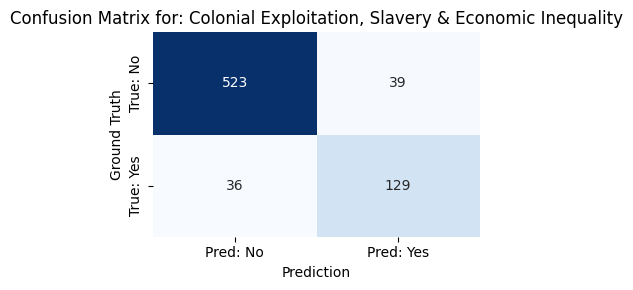

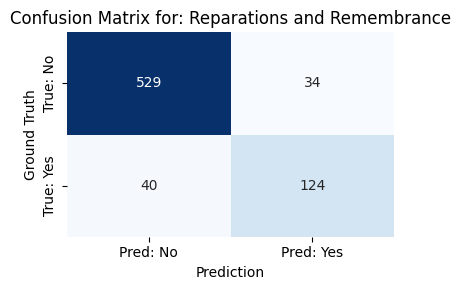

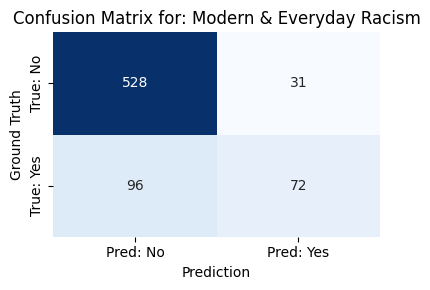

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
# Compute multilabel confusion matrix
ml_cm = multilabel_confusion_matrix(y_true, y_pred)

for i, topic in enumerate(topic_names):
    cm = ml_cm[i]
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
                xticklabels=["Pred: No", "Pred: Yes"],
                yticklabels=["True: No", "True: Yes"])
    plt.title(f"Confusion Matrix for: {topic}")
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()


In [17]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np

# Load tokenizer and model
model_name_or_path = './bertje_slavery-policy/checkpoint-219'  # e.g., './output_dir'
tokenizer = BertTokenizer.from_pretrained("groNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(model_name_or_path)
model.eval()



def predict_topic(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).numpy().flatten()
        pred_idx = np.argmax(probs)
        return labels[pred_idx], probs[pred_idx], probs

# Example
sentence = "herdenking "
topic, confidence, all_probs = predict_topic(sentence)
print(f"Predicted topic: {topic} (Confidence: {confidence:.2f})")
print("All topic probabilities:", dict(zip(labels, all_probs.round(5))))


NameError: name 'labels' is not defined

In [26]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np
import pickle

# --- Load tokenizer and model ---
model_name_or_path = '.Corex+d/checkpoint-219'
tokenizer = BertTokenizer.from_pretrained("groNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(model_name_or_path)
model.eval()

# --- Load label encoder and topic mappings ---
with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)
with open("policy-label2topic.pickle", "rb") as f:
    label2topic = pickle.load(f)
with open("policy-topic2label.pickle", "rb") as f:
    topic2label = pickle.load(f)

# Labels as a list in correct order (int -> topic)
labels = [label2topic[i] for i in range(len(label2topic))]

def predict_topic(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).numpy().flatten()
        pred_idx = np.argmax(probs)
        return labels[pred_idx], probs[pred_idx], probs

# --- Example usage ---
sentence = "Slavernij moet beindigen"
topic, confidence, all_probs = predict_topic(sentence)
print(f"Predicted topic: {topic} (Confidence: {confidence:.2f})")
print("All topic probabilities:", dict(zip(labels, all_probs.round(5))))


HFValidationError: Repo id must use alphanumeric chars or '-', '_', '.', '--' and '..' are forbidden, '-' and '.' cannot start or end the name, max length is 96: '.Corex+d/checkpoint-219'.

In [ ]:
import torch
import numpy as np
import pickle
import json
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import os

# --- Load tokenizer and model ---
Mew_folder = "Corex_topicdata_slavery"
model_name_or_path = "Corex_topicdata_slavery_v4/bertje_policy_checkpoints"  # e.g., './output_dir'
BASEFOLDER = model_name_or_path  # e.g., './output_dir'
tokenizer = BertTokenizer.from_pretrained("groNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(model_name_or_path)
model.eval()

# --- Load label encoder and topic mappings ---
with open(os.path.join(BASEFOLDER, "label_encoder.pkl"), "rb") as f:
    le = pickle.load(f)
with open(os.path.join(BASEFOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(BASEFOLDER, "topic2label.pickle"), "rb") as f:
    topic2label = pickle.load(f)


RESULTS_CSV = os.path.join(BaseFolder, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(MODEL_FOLDER, "lda_topicdata.json")

# --- Load results ---
train_source = pd.read_csv(RESULTS_CSV)

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]


# --- Load topic names and wordlists ---
with open(os.path.join(BASEFOLDER, "topic_names.json"), "r", encoding="utf-8") as f:
    topic_names = json.load(f)
with open(os.path.join(BASEFOLDER, "topic_word_lists.json"), "r", encoding="utf-8") as f:
    topic_word_lists = json.load(f)

# --- Load data (texts and labels) ---
df = train_source.copy()  # assumes train_source is loaded as DataFrame
texts = df['chunk_text'].tolist()
label_ids = df['label'].tolist()
y_true = [label2topic[i] for i in label_ids]

# --- EMBEDDINGS + CONFIDENCE + PREDICTION (ONE PASS) ---
BATCH_SIZE = 16
all_cls_embeds = []
all_confidences = []
all_pred_idxs = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding + predicting"):
    batch_texts = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(
        batch_texts, return_tensors='pt', truncation=True, max_length=256, padding=True
    )
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # CLS embedding from last hidden state
        cls_emb = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_idxs = np.argmax(probs, axis=1)
        confidences = probs[np.arange(len(probs)), pred_idxs]
        # Store results
        all_cls_embeds.append(cls_emb)
        all_confidences.extend(confidences)
        all_pred_idxs.extend(pred_idxs)

embeddings = np.vstack(all_cls_embeds)
confidences = all_confidences
predicted_label_idxs = all_pred_idxs

df['confidence'] = confidences
df['pred_label'] = [label2topic[i] for i in predicted_label_idxs]
df['true_topic'] = y_true

# --- t-SNE REDUCTION ---
perplexity = min(30, len(embeddings)-1)
print(f"Running t-SNE with perplexity={perplexity} on {len(embeddings)} points")
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
reduced = tsne.fit_transform(embeddings)
df['x'] = reduced[:,0]
df['y'] = reduced[:,1]

plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='x', y='y', hue='true_topic', palette='Set1', s=60, alpha=0.8)
plt.title("Topic Clustering (t-SNE of BERTje [CLS] Embeddings)", fontsize=14)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- CHUNK LENGTH (5-letter words) ---
def chunk_length_in_5letter_words(text):
    words = str(text).split()
    return sum(max(1, len(w)//5) for w in words)
df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)

# --- COSINE SIMILARITY TO TOPIC ANCHORS ---
tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
tfidf.fit(topic_anchor_docs + df['chunk_text'].astype(str).tolist())
topic_anchor_vecs = tfidf.transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['true_topic'] == t]
    if sub.empty:
        avg_sims_per_topic.append(0)
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'].astype(str))
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sim = np.mean(sims)
    avg_sims_per_topic.append(avg_sim)

# --- AVERAGE NUMBER OF KEYWORDS PRESENT ---
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(str(chunk).lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

# --- PRINT STATS (TRUE LABEL) ---
print(f"\nOverall average chunk length (in 5-letter words): {df['chunk_5w_len'].mean():.2f}")
print("\n--- Average chunk length (per topic, true label) ---")
for t in topic_names:
    sub = df[df['true_topic'] == t]
    avg_len = sub['chunk_5w_len'].mean() if not sub.empty else 0
    print(f"{t:40s}: {avg_len:.2f}")

print("\n--- Average confidence (per topic, predicted) ---")
for t in topic_names:
    sub = df[df['pred_label'] == t]
    avg_conf = sub['confidence'].mean() if not sub.empty else 0
    print(f"{t:40s}: {avg_conf:.3f}")

# --- SUMMARY TABLE (TRUE LABEL) ---
summary_true = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['true_topic'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_conf_treshold": [
        df[df['true_topic'] == t]['confidence'].mean() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['true_topic'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['true_topic'] == t]['filename'].value_counts().idxmax() if not df[df['true_topic'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['true_topic'] == t]['filename'].value_counts().max() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
})
print("\n--- SUMMARY TABLE (TRUE LABEL) ---\n", summary_true)

# --- SUMMARY TABLE (PREDICTED LABEL) ---
summary_pred = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['pred_label'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_conf_treshold": [
        df[df['pred_label'] == t]['confidence'].mean() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['pred_label'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['pred_label'] == t]['filename'].value_counts().idxmax() if not df[df['pred_label'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['pred_label'] == t]['filename'].value_counts().max() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
})
print("\n--- SUMMARY TABLE (PREDICTED LABEL) ---\n", summary_pred)

# --- (OPTIONAL) Save everything for reproducibility ---
def get_unique_folder(base_name):
    """
    Returns a unique folder name by appending _vN if needed.
    E.g. if 'Corex_topicdata' exists, returns 'Corex_topicdata_v2', etc.
    """
    folder = base_name
    version = 1
    while os.path.exists(folder):
        version += 1
        folder = f"{base_name}_v{version}"
    os.makedirs(folder)
    return folder



SAVEFOLDER = get_unique_folder(new_folder)
os.makedirs(SAVEFOLDER, exist_ok=True)
df.to_csv(os.path.join(SAVEFOLDER, "df_full.csv"), index=False)
np.save(os.path.join(SAVEFOLDER, "embeddings.npy"), embeddings)
np.save(os.path.join(SAVEFOLDER, "tsne_coords.npy"), reduced)
summary_true.to_csv(os.path.join(SAVEFOLDER, "summary_true.csv"), index=False)
summary_pred.to_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"), index=False)
with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "wb") as f:
    pickle.dump(label2topic, f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "wb") as f:
    pickle.dump(topic2label, f)
with open(os.path.join(SAVEFOLDER, "topic_names.json"), "w", encoding="utf-8") as f:
    json.dump(topic_names, f, ensure_ascii=False, indent=2)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "w", encoding="utf-8") as f:
    json.dump(topic_word_lists, f, ensure_ascii=False, indent=2)
params = {
    "model_name_or_path": model_name_or_path,
    "BATCH_SIZE": BATCH_SIZE,
    "tsne_perplexity": perplexity,
}
with open(os.path.join(SAVEFOLDER, "script_params.json"), "w") as f:
    json.dump(params, f, indent=2)


FileNotFoundError: [Errno 2] No such file or directory: 'Corex_topicdata_slavery_v4/bertje_policy_checkpoints/checkpoint-147\\label_encoder.pkl'

In [44]:
import os
import json
import pickle
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
LOAD_FOLDER = "Corex_topicdata_slavery_v4"  # Folder where metadata, mappings, and checkpoints live
CHECKPOINT_DIR = os.path.join(LOAD_FOLDER, "bertje_policy_checkpoints")
Save_name= "Bertje_slaveryV1"

# --- Load results ---
RESULTS_CSV = os.path.join(LOAD_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(LOAD_FOLDER, "lda_topicdata.json")
train_source = pd.read_csv(RESULTS_CSV)

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]


# === Find latest checkpoint inside bertje_policy_checkpoints ===
def find_latest_checkpoint(checkpoint_dir):
    subfolders = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, f))]
    subfolders = sorted(subfolders, key=os.path.getmtime, reverse=True)
    return subfolders[0] if subfolders else checkpoint_dir

latest_checkpoint = find_latest_checkpoint(CHECKPOINT_DIR)
print(f"Using model from: {latest_checkpoint}")

# === Load tokenizer and model ===
tokenizer = BertTokenizer.from_pretrained("GroNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(latest_checkpoint)
model.eval()

# ---- LABEL PREPARATION ----
import ast

# Convert string like "[False, True, True]" to Python list
train_source['label_bools'] = train_source['topic_assigned'].apply(ast.literal_eval)

# Convert list of bools to list of topic names
def bools_to_labels(bools):
    return [topic_names[i] for i, val in enumerate(bools) if val]

train_source['labels'] = train_source['label_bools'].apply(bools_to_labels)


# === Load label encoder and topic mappings ===
with open(os.path.join(LOAD_FOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)
with open(os.path.join(LOAD_FOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(LOAD_FOLDER, "topic2label.json"), "r", encoding="utf-8") as f:
    topic2label = json.load(f)




# This assumes 'train_source' is already loaded into memory.
texts = train_source['chunk_text'].tolist()
label_lists = train_source['labels'].tolist()
y_true = [[label2topic[label] for label in label_list] for label_list in label_lists]




# === Generate BERT embeddings, predictions, and confidences ===
BATCH_SIZE = 16
all_cls_embeds, all_confidences, all_pred_idxs = [], [], []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding + predicting"):
    batch_texts = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, max_length=256, padding=True)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        cls_emb = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_idxs = np.argmax(probs, axis=1)
        confs = probs[np.arange(len(probs)), pred_idxs]

    all_cls_embeds.append(cls_emb)
    all_confidences.extend(confs)
    all_pred_idxs.extend(pred_idxs)

embeddings = np.vstack(all_cls_embeds)

# === Build dataframe ===
topic2label = {int(k): v for k, v in topic2label.items()}

df = train_source.copy()
df['confidence'] = all_confidences
df['pred_label'] = [topic2label[i] for i in all_pred_idxs]
df['true_topic'] = y_true

# === t-SNE dimensionality reduction ===
perplexity = min(30, len(embeddings) - 1)
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
reduced = tsne.fit_transform(embeddings)
df['x'] = reduced[:, 0]
df['y'] = reduced[:, 1]

# === Chunk length estimate ===
def chunk_length_in_5letter_words(text):
    words = str(text).split()
    return sum(max(1, len(w) // 5) for w in words)

df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)

# === Cosine similarity to topic anchors ===
tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
tfidf.fit(topic_anchor_docs + df['chunk_text'].astype(str).tolist())
topic_anchor_vecs = tfidf.transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['true_topic'] == t]
    if sub.empty:
        avg_sims_per_topic.append(0)
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'].astype(str))
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sims_per_topic.append(np.mean(sims))

# === Keyword match count ===
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(str(chunk).lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

# === Summary Tables ===
summary_true = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['true_topic'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_conf_treshold": [
        df[df['true_topic'] == t]['confidence'].mean() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['true_topic'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['true_topic'] == t]['filename'].value_counts().idxmax() if not df[df['true_topic'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['true_topic'] == t]['filename'].value_counts().max() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
})

summary_pred = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['pred_label'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_conf_treshold": [
        df[df['pred_label'] == t]['confidence'].mean() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['pred_label'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['pred_label'] == t]['filename'].value_counts().idxmax() if not df[df['pred_label'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['pred_label'] == t]['filename'].value_counts().max() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
})

# === Save outputs ===
def get_unique_folder(base_name):
    folder = base_name
    version = 1
    while os.path.exists(folder):
        version += 1
        folder = f"{base_name}_v{version}"
    os.makedirs(folder)
    return folder

SAVEFOLDER = get_unique_folder(Save_name)

df.to_csv(os.path.join(SAVEFOLDER, "df_full.csv"), index=False)
np.save(os.path.join(SAVEFOLDER, "embeddings.npy"), embeddings)
np.save(os.path.join(SAVEFOLDER, "tsne_coords.npy"), reduced)
summary_true.to_csv(os.path.join(SAVEFOLDER, "summary_true.csv"), index=False)
summary_pred.to_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"), index=False)

with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "wb") as f:
    pickle.dump(label2topic, f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "wb") as f:
    pickle.dump(topic2label, f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)
with open(os.path.join(SAVEFOLDER, "topic_names.json"), "w", encoding="utf-8") as f:
    json.dump(topic_names, f, ensure_ascii=False, indent=2)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "w", encoding="utf-8") as f:
    json.dump(topic_word_lists, f, ensure_ascii=False, indent=2)

params = {
    "model_checkpoint": latest_checkpoint,
    "base_folder": LOAD_FOLDER,
    "BATCH_SIZE": BATCH_SIZE,
    "tsne_perplexity": perplexity,
    "generated_on": datetime.now().isoformat(),
}
with open(os.path.join(SAVEFOLDER, "script_params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"All results saved in: {SAVEFOLDER}")


Using model from: Corex_topicdata_slavery_v4\bertje_policy_checkpoints\checkpoint-147


Embedding + predicting: 100%|██████████| 91/91 [05:17<00:00,  3.49s/it]


All results saved in: Bertje_slaveryV1


In [12]:
print(df_full.head(10))

NameError: name 'df_full' is not defined

In [18]:
import os
import pandas as pd
import numpy as np
import pickle
import json

# Set your save folder path
SAVEFOLDER = "Bertje_slaveryV1"

# Load DataFrame and arrays
df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))
embeddings = np.load(os.path.join(SAVEFOLDER, "embeddings.npy"))
tsne_coords = np.load(os.path.join(SAVEFOLDER, "tsne_coords.npy"))

# Load summaries
summary_true = pd.read_csv(os.path.join(SAVEFOLDER, "summary_true.csv"))
summary_pred = pd.read_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"))

# Load pickled dictionaries and encoder
with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "rb") as f:
    topic2label = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

# Load JSON files
with open(os.path.join(SAVEFOLDER, "topic_names.json"), "r", encoding="utf-8") as f:
    topic_names = json.load(f)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "r", encoding="utf-8") as f:
    topic_word_lists = json.load(f)

# Load script parameters
with open(os.path.join(SAVEFOLDER, "script_params.json"), "r", encoding="utf-8") as f:
    script_params = json.load(f)

print("All files successfully loaded.")
print(df.head)

All files successfully loaded.
<bound method NDFrame.head of                                                filename  \
0     Allen e.a. - 2023 - Staat en slavernij het Ned...   
1     Allen e.a. - 2023 - Staat en slavernij het Ned...   
2     Allen e.a. - 2023 - Staat en slavernij het Ned...   
3     Allen e.a. - 2023 - Staat en slavernij het Ned...   
4     Allen e.a. - 2023 - Staat en slavernij het Ned...   
...                                                 ...   
1448                              ZWART_MANIFEST.46.txt   
1449                               ZWART_MANIFEST.7.txt   
1450                               ZWART_MANIFEST.5.txt   
1451                               ZWART_MANIFEST.8.txt   
1452                               ZWART_MANIFEST.9.txt   

                                               filepath  document_type  year  \
0     slavery_text\Allen e.a. - 2023 - Staat en slav...            NaN   NaN   
1     slavery_text\Allen e.a. - 2023 - Staat en slav...            NaN

In [3]:
print(df['cosine_weighted'].iloc[0])
print(type(df['cosine_weighted'].iloc[0]))


[0.34644711940374345, 0.0, 0.0]
<class 'str'>


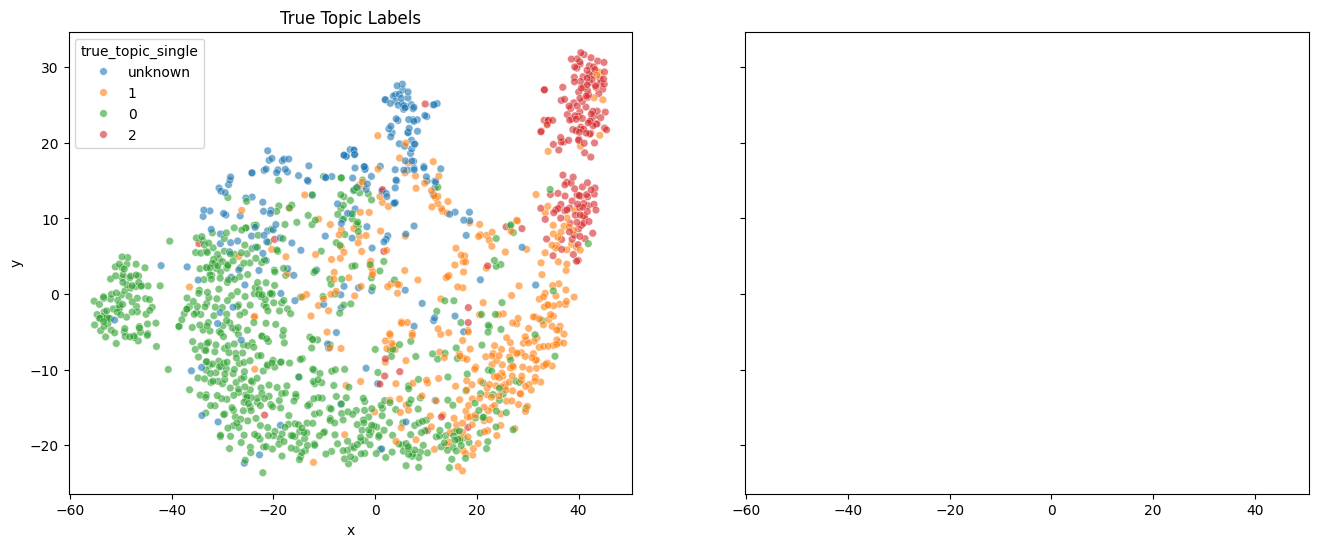

In [21]:
import ast
from scipy.stats import entropy
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

def safe_to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return []

df['cosine_weighted'] = df['cosine_weighted'].apply(safe_to_list)
df['true_topic'] = df['true_topic'].apply(safe_to_list)



# Determine main topic (highest weighted cosine)
df['main_topic'] = df['cosine_weighted'].apply(
    lambda x: topic_names[np.argmax(x)] if isinstance(x, list) and len(x) == len(topic_names) else "unknown"
)

def tooltip_text(row):
    if isinstance(row['cosine_weighted'], list):
        topic_conf = [
            f"{topic_names[i]}: {round(score, 2)}"
            for i, score in enumerate(row['cosine_weighted'])
            if score > 0
        ]
        return "\n".join(topic_conf)
    return ""

df['tooltip'] = df.apply(tooltip_text, axis=1)


fig = px.scatter(
    df,
    x='x', y='y',
    color='main_topic',
    hover_data={
        'filename': True,
        'main_topic': True,
        'tooltip': True,
        'x': False, 'y': False,
    },
    title="Chunks Colored by Most Likely Topic (with Tooltips)"
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()


# Create predicted and true labels (single-label based on highest confidence)
df['true_topic_single'] = df['true_topic'].apply(lambda x: x[0] if x else "unknown")
df['pred_topic_single'] = df['pred_label']  # already topic name string


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Plot true labels
sns.scatterplot(
    data=df,
    x='x', y='y',
    hue='true_topic_single',
    palette='tab10',
    alpha=0.6,
    s=30,
    ax=axes[0]
)
axes[0].set_title("True Topic Labels")

# --- Predicted labels ---
fig_pred = px.scatter(
    df,
    x='x', y='y',
    color='pred_topic_single',
    hover_data={'filename': True, 'pred_topic_single': True, 'confidence': True},
    title="Predicted Topic Labels"
)
fig_pred.update_traces(marker=dict(size=6, opacity=0.7))
fig_pred.show()


from scipy.stats import entropy

fig_conf = px.scatter(
    df,
    x='x', y='y',
    color='confidence',
    color_continuous_scale='Viridis',
    hover_data={'filename': True, 'pred_topic_single': True, 'confidence': True},
    title="Prediction Strength (Confidence Score)"
)
fig_conf.update_traces(marker=dict(size=6, opacity=0.8))
fig_conf.show()



In [14]:
# Fix predicted and true topic names
df['true_topic_single'] = df['true_topic'].apply(
    lambda x: topic_names[x[0]] if isinstance(x, list) and x else "unknown"
)

df['pred_topic_single'] = df['pred_label']  # already topic name string

import plotly.express as px

# --- True labels ---
fig_true = px.scatter(
    df,
    x='x', y='y',
    color='true_topic_single',
    hover_data={'filename': True, 'true_topic_single': True},
    title="True Topic Labels"
)
fig_true.update_traces(marker=dict(size=6, opacity=0.7))
fig_true.show()

# --- Predicted labels ---
fig_pred = px.scatter(
    df,
    x='x', y='y',
    color='pred_topic_single',
    hover_data={'filename': True, 'pred_topic_single': True, 'confidence': True},
    title="Predicted Topic Labels"
)
fig_pred.update_traces(marker=dict(size=6, opacity=0.7))
fig_pred.show()


fig_conf = px.scatter(
    df,
    x='x', y='y',
    color='confidence',
    color_continuous_scale='Viridis',
    hover_data={'filename': True, 'pred_topic_single': True, 'confidence': True},
    title="Prediction Strength (Confidence Score)"
)
fig_conf.update_traces(marker=dict(size=6, opacity=0.8))
fig_conf.show()



In [10]:
import ast
import plotly.express as px
import pandas as pd
from scipy.stats import entropy

# --- PREPROCESS ---

def safe_to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return []

df['cosine_weighted'] = df['cosine_weighted'].apply(safe_to_list)
df['true_topic'] = df['true_topic'].apply(safe_to_list)
df['pred_label'] = df['pred_label'].apply(safe_to_list)

# Main topic from cosine-weighted
df['main_topic'] = df['cosine_weighted'].apply(
    lambda x: topic_names[np.argmax(x)] if isinstance(x, list) and len(x) == len(topic_names) else "unknown"
)

# Tooltip with all cosine-weighted topic values
def tooltip_text(row):
    if isinstance(row['cosine_weighted'], list):
        topic_conf = [
            f"{topic_names[i]}: {round(score, 2)}"
            for i, score in enumerate(row['cosine_weighted'])
            if score > 0
        ]
        return "\n".join(topic_conf)
    return ""

df['tooltip'] = df.apply(tooltip_text, axis=1)

# --- TRUE & PREDICTED LABELS ---
df['true_topic_single'] = df['true_topic'].apply(
    lambda x: topic_names[x[0]] if isinstance(x, list) and len(x) > 0 and isinstance(x[0], int) and x[0] < len(topic_names) else "unknown"
)

df['pred_topic_single'] = df['pred_label'].apply(
    lambda x: topic_names[np.argmax(x)] if isinstance(x, list) and len(x) == len(topic_names) else "unknown"
)

# --- ENTROPY ---
df['entropy'] = df['pred_label'].apply(
    lambda x: entropy(x) if isinstance(x, list) and len(x) > 0 else None
)

# --- PLOT 1: MAIN TOPIC BY COSINE ---

fig1 = px.scatter(
    df,
    x='x', y='y',
    color='main_topic',
    hover_data={
        'filename': True,
        'main_topic': True,
        'tooltip': True
    },
    title="Chunks Colored by Most Likely Topic (Cosine Weighted)"
)
fig1.update_traces(marker=dict(size=6, opacity=0.7))
fig1.show()

# --- PLOT 2: TRUE TOPIC ---

fig2 = px.scatter(
    df,
    x='x', y='y',
    color='true_topic_single',
    hover_data={
        'filename': True,
        'true_topic_single': True
    },
    title="True Topic Labels (Interactive)"
)
fig2.update_traces(marker=dict(size=6, opacity=0.7))
fig2.show()

# --- PLOT 3: PREDICTED TOPIC ---

fig3 = px.scatter(
    df,
    x='x', y='y',
    color='pred_topic_single',
    hover_data={
        'filename': True,
        'pred_topic_single': True,
        'confidence': True
    },
    title="Predicted Topic Labels (Interactive)"
)
fig3.update_traces(marker=dict(size=6, opacity=0.7))
fig3.show()

# --- PLOT 4: ENTROPY (UNCERTAINTY) ---

fig4 = px.scatter(
    df[df['entropy'].notna()],
    x='x', y='y',
    color='entropy',
    color_continuous_scale='Viridis_r',
    hover_data={
        'filename': True,
        'entropy': True,
        'pred_topic_single': True
    },
    title="Prediction Uncertainty (Entropy of Topic Distribution)"
)
fig4.update_traces(marker=dict(size=6, opacity=0.7))
fig4.show()


In [11]:
print(df['pred_label'].iloc[0])
print(type(df['pred_label'].iloc[0]))
print(len(df['pred_label'].iloc[0]))
print(topic_names)
print(len(topic_names))


[]
<class 'list'>
0
['Colonial Exploitation, Slavery & Economic Inequality', 'Reparations and Remembrance', 'Modern & Everyday Racism']
3


                                                      accuracy  confidence  \
true_label_single                                                            
Modern & Everyday Racism                                 0.929       0.942   
Colonial Exploitation, Slavery & Economic Inequality     0.765       0.841   
Reparations and Remembrance                              0.608       0.725   
[]                                                       0.000       0.663   

                                                      n_chunks  
true_label_single                                               
Modern & Everyday Racism                                   183  
Colonial Exploitation, Slavery & Economic Inequality       690  
Reparations and Remembrance                                355  
[]                                                         225  


C:\Users\Home\AppData\Local\Temp\ipykernel_35920\1632634518.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Correctly Classified')


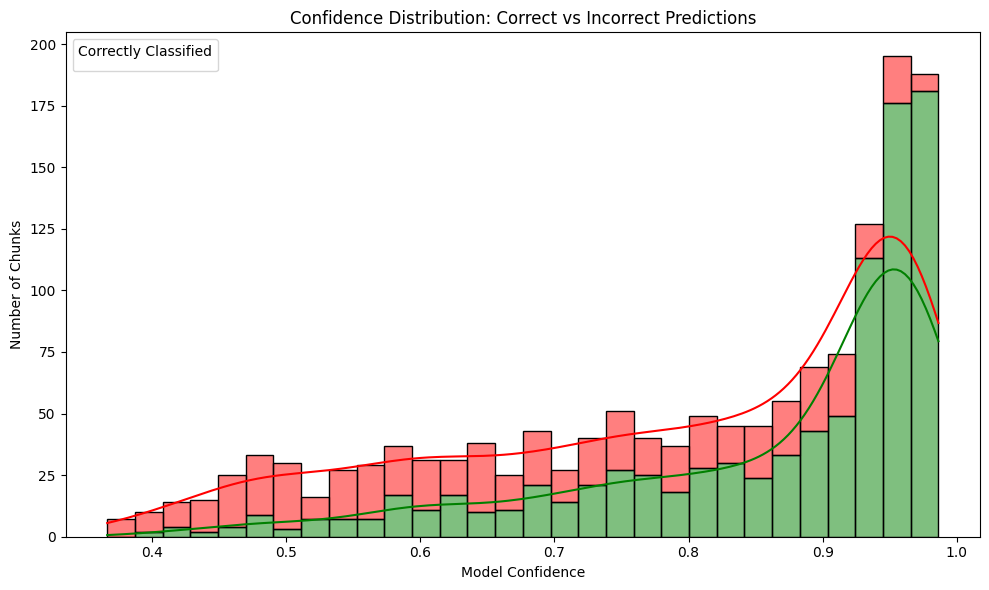

C:\Users\Home\AppData\Local\Temp\ipykernel_35920\1632634518.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


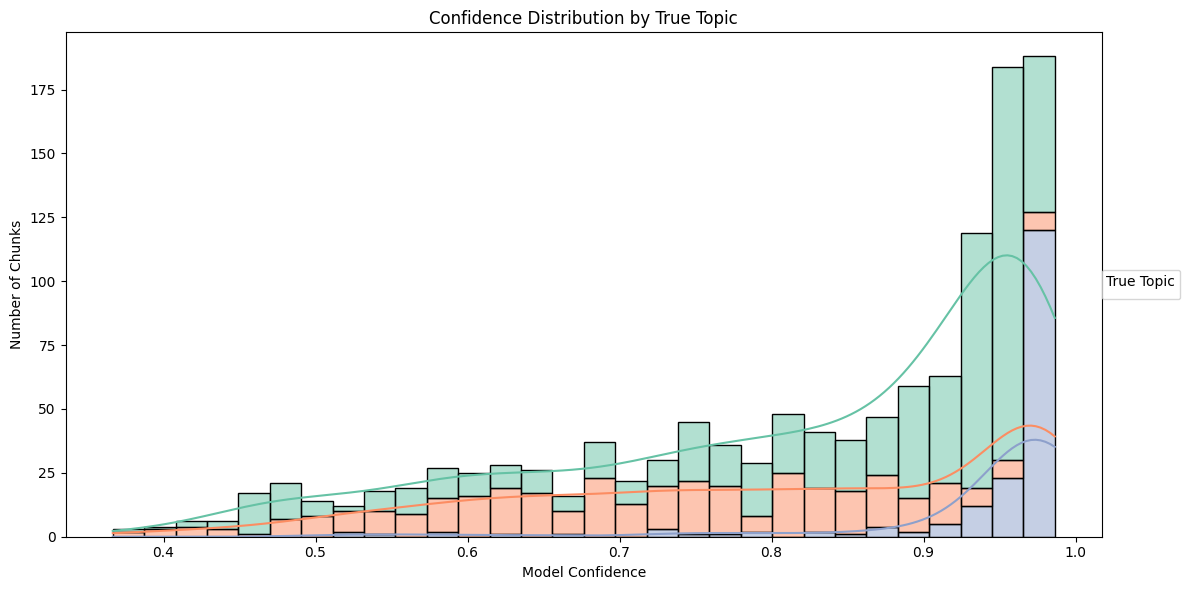

In [61]:

import matplotlib.pyplot as plt
import seaborn as sns


# Convert binary list to actual topic names
df['true_topic'] = df['label_bools'].apply(lambda x: [topic_names[i] for i, val in enumerate(x) if val])

df['true_label_single'] = df['true_topic'].apply(lambda x: x[0] if isinstance(x, list) and x else str(x))


grouped = df.groupby('true_label_single').agg({
    'correct': 'mean',
    'confidence': 'mean',
    'filename': 'count'
}).rename(columns={'correct': 'accuracy', 'filename': 'n_chunks'})

print(grouped.sort_values('accuracy', ascending=False).round(3))

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='confidence', hue='correct', bins=30, kde=True, stat='count', multiple='stack', palette={True: 'green', False: 'red'})
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.xlabel("Model Confidence")
plt.ylabel("Number of Chunks")
plt.legend(title='Correctly Classified')
plt.tight_layout()
plt.show()

# Optional: make sure topics appear in consistent order
df['true_label_single'] = pd.Categorical(df['true_label_single'], categories=topic_names, ordered=True)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='confidence',
    hue='true_label_single',
    bins=30,
    kde=True,
    multiple='stack',
    palette='Set2'  # Or 'Set1', 'tab10', 'muted' etc.
)

plt.title("Confidence Distribution by True Topic")
plt.xlabel("Model Confidence")
plt.ylabel("Number of Chunks")
plt.legend(
    title="True Topic",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    borderaxespad=0.,
    fontsize='small',
    title_fontsize='medium'
)
plt.tight_layout()
plt.show()


In [11]:
print(df.columns)

Index(['filename', 'filepath', 'document_type', 'year', 'chunk_num',
       'chunk_text', 'topic', 'cosine', 'cosine_weighted', 'topic_probs',
       'topic_assigned', 'x_umap', 'y_umap'],
      dtype='object')


In [62]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
  # Increase to 300 chars (or any large number)

# Ensure all lists are the same length
min_len = min(len(confidences), len(texts), len(true_labels), len(pred_labels))
df = pd.DataFrame({
    'confidence': confidences[:min_len],
    'text': texts[:min_len],
    'true_label': true_labels[:min_len],
    'pred_label': pred_labels[:min_len]
})

# Sort by confidence
high_conf_threshold = df['confidence'].quantile(0.10)
df_high = df[df['confidence'] >= high_conf_threshold]
print(df_high[['confidence', 'true_label', 'pred_label', 'text']])



NameError: name 'confidences' is not defined

In [65]:
pip install umap-learn scikit-learn


   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.8 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
    --------------------------------------- 0.5/30.3 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.3 MB 1.5 MB/s eta 0:00:20
   --- ------------------------------------ 2.4/30.3 MB 3.9 MB/s eta 0:00:08
   ----- ---------------------------------- 4.5/30.3 MB 5.6 MB/s eta 0:00:05
   ------- -------------------------------- 6.0/30.3 MB 6.2 MB/s eta 0:00:04
   ---------- ----------------------------- 8.1/30.3 MB 6.8 MB/s eta 0:00:04
   ------------ --------------------------- 9.7/30.3 MB 7.0 MB/s eta 0:00:03
   -------------- ------------------------- 11.3/30.3 MB 7.0 MB/s eta 0:00:03
   ----------------- ---------------------- 13.4/30.3 MB 7.4 MB/s eta 0:00:03
   ------------------

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# --- TF-IDF Transformation ---
vectorizer = TfidfVectorizer(max_features=2000, stop_words=list(all_stopwords))
X_tfidf = vectorizer.fit_transform(df['chunk_text'])

# --- Dimensionality Reduction ---
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_tfidf)

# --- Add coordinates to DataFrame ---
df['x_umap'] = X_umap[:, 0]
df['y_umap'] = X_umap[:, 1]

# --- Plot 1: True Labels ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='x_umap', y='y_umap',
    hue='true_label_single',
    palette='tab10',
    alpha=0.6,
    s=30
)
plt.title("2D Scatterplot of Chunks by True Topic")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Plot 2: Predicted Labels ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='x_umap', y='y_umap',
    hue='pred_label',
    palette='tab10',
    alpha=0.6,
    s=30
)
plt.title("2D Scatterplot of Chunks by Predicted Topic")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


c:\Users\Home\policy-analysis\.conda\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eilanden'] not in stop_words.
  warnings.warn(
c:\Users\Home\policy-analysis\.conda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: Could not interpret value `true_label_single` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

##Visual

In [139]:
# Folder and config
SOURCE_FOLDER = r"C:\Users\Home\policy-analysis\Policyarchive_text\jaarverslagen\2015\jaarverslag-beheer-staatsdeelnemingen-2014"  # Original texts
SAVEFOLDER = "bertje_slavery-policy\checkpoint-219"
CHUNK_SIZE = 300  # words per chunk
target_file = "jaarverslag-beheer-staatsdeelnemingen-2014.32.txt"

HIGHLIGHT_COLORS = [
    "#fffbcc",  # butter
    "#eaf9fd",  # cloud blue
    "#eaffea",  # hint of mint
    "#fff0fa",  # soft pink
    "#fff3e6",  # cream
]

# Load outputs
import os, json, pickle
import pandas as pd
import numpy as np

df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))
label2topic = pickle.load(open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb"))
topic_names = json.load(open(os.path.join(SAVEFOLDER, "topic_names.json"), encoding="utf-8"))

# Make sure the order is consistent (lowest label gets first color)
import numpy as np

# Find all unique labels in your df and assign colors accordingly
unique_labels = sorted(df['label'].unique())
label2color = {label: HIGHLIGHT_COLORS[i % len(HIGHLIGHT_COLORS)] for i, label in enumerate(unique_labels)}

# Map label integer to topic name
label2topic = df[['label', 'pred_label']].drop_duplicates().set_index('label')['pred_label'].to_dict()




def highlight_chunks_in_text(
    text, chunk_labels, chunk_confidence, label2topic, label2color, chunk_size=300
):
    words = text.split()
    html = ""
    for i, (label, conf) in enumerate(zip(chunk_labels, chunk_confidence)):
        chunk_words = words[i*chunk_size : (i+1)*chunk_size]
        chunk_text = " ".join(chunk_words)
        color = label2color[label]
        topic_name = label2topic[label]
        tooltip = f"Topic: {topic_name}<br>Confidence: {conf:.2f}"
        html += (
            f'<span style="background:{color};color:#111;'
            f'padding:2px 6px;border-radius:6px;margin:2px;'
            f'border:1px solid #eee;" title="{tooltip}">'
            f'{chunk_text}</span> '
        )
    return html




chunks = df[df['filename'] == target_file].sort_values('chunk_num')
chunk_labels = chunks['label'].astype(int).tolist()
chunk_confidence = chunks['confidence'].tolist()

with open(os.path.join(SOURCE_FOLDER, target_file), encoding='utf-8') as f:
    original_text = f.read().replace('\n', ' ')

html = highlight_chunks_in_text(
    original_text,
    chunk_labels,
    chunk_confidence,
    label2topic,
    label2color,
    chunk_size=300
)

from IPython.display import display, HTML
display(HTML(html))
